# Lab 6 - Vision Transformer

**Course**: Deep Learning for Image Analysis

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:** 🗓️ **Saturday, May 2nd (23:59)**

---

## Learning objectives
Vision Transformer (ViT-B/16 base version) vs ResNet-18  

By the end of this lab, you should be able to:

1. Split an image into patches and understand image tokens.
2. Convert patches into embeddings.
3. Add positional embeddings and a `[CLS]` token.
4. Inspect a pretrained Vision Transformer.
5. Fine-tune pretrained ViT and ResNet models using transfer learning.
6. Compare CNN vs ViT behavior in terms of accuracy, speed, and architecture.


We will **not train ViT from scratch**. That would require large datasets and strong hardware.  
Instead, we will:

- build small components manually for understanding,
- load pretrained models,
- replace their classification heads,
- freeze the backbones,
- train only the final classifiers.

>⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.


## 0. Setup

This notebook supports both:

- **Google Colab with GPU**
- **Local CPU laptops**

On CPU, use a smaller subset of the dataset and fewer epochs.

In [40]:
import os
import time
import random
import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


In [41]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IS_GPU = device.type == "cuda"

CONFIG = {
    "image_size": 224,
    "patch_size": 16,
    "num_classes": 10,
    "batch_size": 32 if IS_GPU else 8,
    "num_workers": 2 if IS_GPU else 0,
    "train_subset": 3000 if IS_GPU else 600,
    "test_subset": 1000 if IS_GPU else 300,
    "epochs": 3 if IS_GPU else 1,
    "lr": 1e-3,
}
CONFIG

Using device: cuda


{'image_size': 224,
 'patch_size': 16,
 'num_classes': 10,
 'batch_size': 32,
 'num_workers': 2,
 'train_subset': 3000,
 'test_subset': 1000,
 'epochs': 3,
 'lr': 0.001}

## 1. Dataset: CIFAR-10 resized to 224×224

CIFAR-10 images are originally **32×32**, but ImageNet-pretrained ViT and ResNet models expect around **224×224** input images.

So we resize CIFAR-10 images to 224×224 and normalize them using ImageNet statistics.

In [42]:
# ImageNet normalization values used by pretrained torchvision models.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

root = "./data"
train_full = datasets.CIFAR10(root=root, train=True, download=True, transform=train_transform)
test_full = datasets.CIFAR10(root=root, train=False, download=True, transform=test_transform)

class_names = train_full.classes
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [43]:
# Use a subset to keep the lab fas :)
train_indices = list(range(CONFIG["train_subset"]))
test_indices = list(range(CONFIG["test_subset"]))

train_ds = Subset(train_full, train_indices)
test_ds = Subset(test_full, test_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
)

test_loader = DataLoader(
    test_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
)

print("Train samples:", len(train_ds))
print("Test samples:", len(test_ds))
print("Classes:", class_names)

Train samples: 3000
Test samples: 1000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


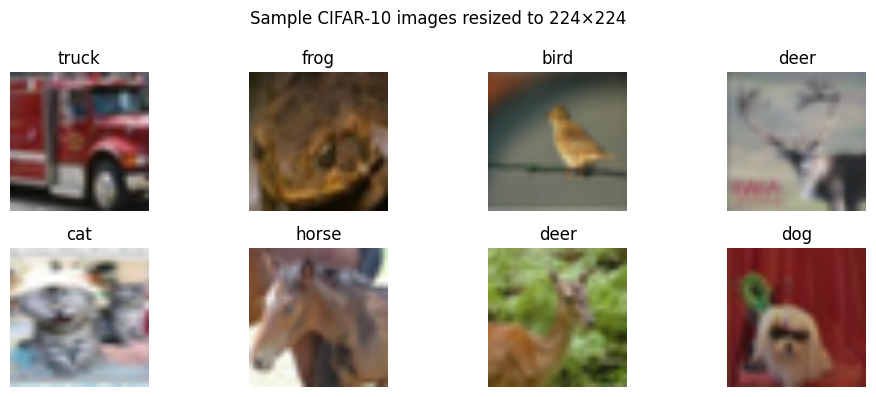

In [44]:
def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Undo ImageNet normalization for visualization."""
    img = img_tensor.clone().detach().cpu()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img = img * std + mean
    return img.clamp(0, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(denormalize(images[i]).permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 images resized to 224×224")
plt.tight_layout()
plt.show()

# Part A : Build ViT input components manually

Before using a pretrained ViT, we manually build the input pipeline:

1. Image → patches
2. Patches → flattened vectors
3. Flattened vectors → embeddings
4. Add positional embeddings
5. Add `[CLS]` token

## 2. Step 1 : Split image into patches

For ViT-B/16:

- image size = 224×224
- patch size = 16×16
- number of patches per side = 224 / 16 = 14
- total patches = 14 × 14 = 196

Each patch becomes one token.

Image shape: torch.Size([3, 224, 224])
Label: truck


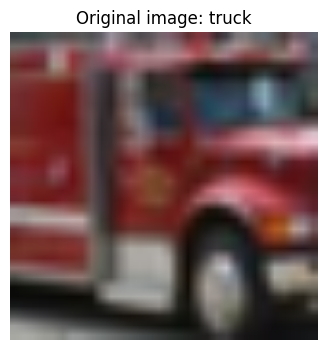

In [45]:
# Pick one image for visualization.
sample_img = images[0]  # shape: [3, 224, 224]
sample_label = labels[0].item()
print("Image shape:", sample_img.shape)
print("Label:", class_names[sample_label])

plt.figure(figsize=(4, 4))
plt.imshow(denormalize(sample_img).permute(1, 2, 0))
plt.title(f"Original image: {class_names[sample_label]}")
plt.axis("off")
plt.show()

In [46]:
def image_to_patches(img, patch_size=16):
    """
    Convert one image tensor [C, H, W] into patches.

    Expected output shape:
        [num_patches, C, patch_size, patch_size]
    """
    C, H, W = img.shape
    assert H % patch_size == 0 and W % patch_size == 0, "Image size must be divisible by patch size."

    # TODO 1:
    # Use torch.unfold to split the image into non-overlapping patches.
    # Documentation: https://docs.pytorch.org/docs/stable/generated/torch.nn.Unfold.html
    # Add a batch dimension, then unfold
    img_batch = img.unsqueeze(0) # [1, C, H, W]

    # Unfold to get patches
    # Output shape: [1, C * P * P, num_patches]
    unfolded = torch.nn.functional.unfold(img_batch, kernel_size=(patch_size, patch_size), stride=(patch_size, patch_size))

    # Reshape to [num_patches, C, patch_size, patch_size]
    # Remove batch dim: [C * P * P, num_patches]
    # Transpose: [num_patches, C * P * P]
    # Reshape: [num_patches, C, P, P]
    patches = unfolded.squeeze(0).transpose(0, 1).reshape(-1, C, patch_size, patch_size)

    # TODO: replace None with your implementation.
    return patches

In [47]:
# Test your implementation.
patches = image_to_patches(sample_img, CONFIG["patch_size"])

# TODO 2:
# Print the shape of patches.
# Expected: [196, 3, 16, 16]
print("Patches shape:", patches.shape)

Patches shape: torch.Size([196, 3, 16, 16])


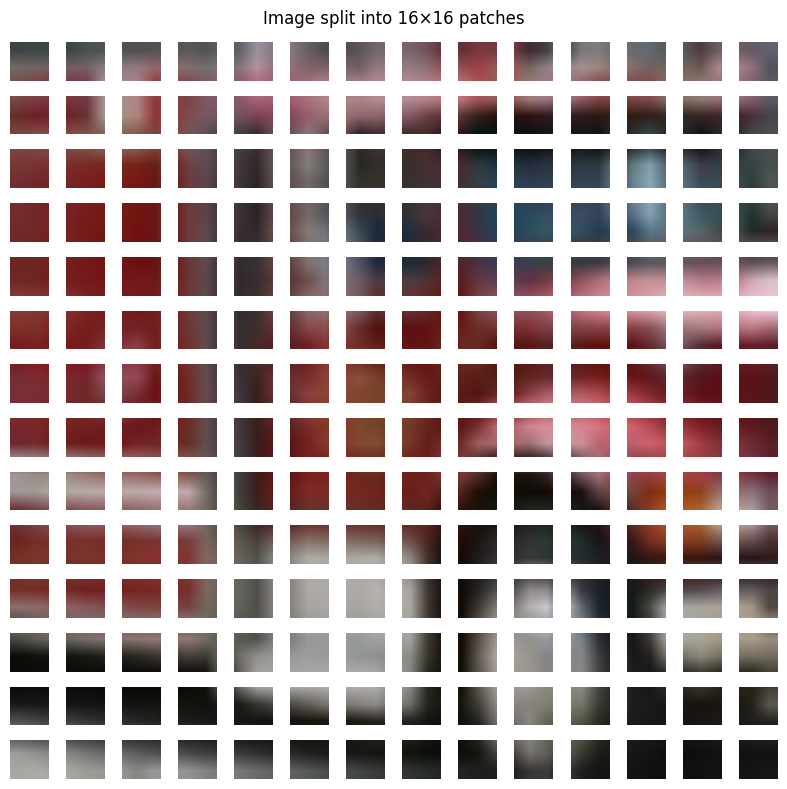

In [48]:
def show_patch_grid(patches, grid_size=14, max_patches=196):
    """Visualize patches in their original grid order."""
    plt.figure(figsize=(8, 8))
    for i in range(min(max_patches, patches.shape[0])):
        plt.subplot(grid_size, grid_size, i + 1)
        patch = denormalize(patches[i]).permute(1, 2, 0)
        plt.imshow(patch)
        plt.axis("off")
    plt.suptitle("Image split into 16×16 patches")
    plt.tight_layout()
    plt.show()

show_patch_grid(patches, grid_size=CONFIG["image_size"] // CONFIG["patch_size"])

### Checkpoint question

If we change the patch size from 16×16 to 32×32 while keeping the image size 224×224:

1. How many patches do we get?
2. What happens to computation cost?
3. What happens to spatial detail?

**Answer:**

1.  **Nombre de patches :**
    *   Avec une taille d'image de 224x224 et des patches de 16x16, nous obtenons (224/16) * (224/16) = 14 * 14 = 196 patches.
    *   Avec une taille d'image de 224x224 et des patches de 32x32, nous obtenons (224/32) * (224/32) = 7 * 7 = 49 patches.
    Le nombre de patches diminue considérablement de 196 à 49.

2.  **Coût de calcul :**
    *   Le coût de calcul dans les Vision Transformers (en particulier pour le mécanisme d'auto-attention) est quadratique par rapport au nombre de tokens (patches). Étant donné que le nombre de patches diminue de manière significative, le coût de calcul diminuera également de manière substantielle.

3.  **Détail spatial :**
    *   Chaque patch représente une région locale de l'image. Des patches plus grands signifient que chaque patch couvre une zone plus étendue de l'image. Par conséquent, le modèle perd en granularité et en capacité à capturer des détails spatiaux fins. Le niveau de détail spatial que le modèle peut percevoir diminue.

## 3. Step 2.1 : Patch → Embedding

A transformer cannot process image patches directly. It expects vectors.

For each patch:

1. Flatten it into a vector.
2. Apply a linear projection to map it into an embedding dimension.

For RGB 16×16 patches:

\[
16 x 16 x 3 = 768
\]

So each flattened patch has 768 values.

In [49]:
patch_size = CONFIG["patch_size"]
patch_dim = 3 * patch_size * patch_size
embed_dim = 768

print("Patch dimension:", patch_dim)
print("Embedding dimension:", embed_dim)

Patch dimension: 768
Embedding dimension: 768


In [50]:
def flatten_patches(patches):
    """
    Input:
        patches: [num_patches, C, P, P]
    Output:
        flat_patches: [num_patches, C*P*P]
    """
    # TODO 3:
    # Flatten each patch into a 1D vector.
    flat_patches = patches.view(patches.size(0), -1)
    return flat_patches
flat_patches = flatten_patches(patches)
print("Flattened patches shape:", flat_patches.shape)

Flattened patches shape: torch.Size([196, 768])


In [51]:
class PatchEmbedding(nn.Module):
    def __init__(self, patch_dim, embed_dim):
        super().__init__()
        # TODO 4:
        # Define a linear layer that maps patch_dim -> embed_dim.
        self.proj = nn.Linear(patch_dim, embed_dim)

    def forward(self, flat_patches):
        # TODO 5:
        # Apply the projection to flat_patches.
        embeddings = self.proj(flat_patches)
        return embeddings

In [52]:
num_patches = (CONFIG["image_size"] // CONFIG["patch_size"]) ** 2
print("Number of patches:", num_patches)

class AddPositionEmbedding(nn.Module):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        # TODO 6:
        # Create learnable positional embeddings of shape [1, num_patches, embed_dim].
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))

    def forward(self, patch_embeddings):
        """
        patch_embeddings shape can be:
            [num_patches, embed_dim] or [batch, num_patches, embed_dim]
        """
        if patch_embeddings.dim() == 2:
            patch_embeddings = patch_embeddings.unsqueeze(0)

        # TODO 7:
        # Add pos embeddings to patch embeddings.
        x = patch_embeddings + self.pos_embed
        return x

Number of patches: 196


### Checkpoint question

What is the difference between:

- the flattened patch vector
- the patch embedding vector

Why do we need the linear projection?

**Answer:**

-   **Flattened patch vector**: This is the raw patch data reshaped into a 1D vector. For an RGB 16x16 patch, it would be 16 * 16 * 3 = 768 dimensions. It contains the raw pixel values in a sequential order.

-   **Patch embedding vector**: This is the result of applying a linear projection (and potentially other transformations) to the flattened patch vector. It maps the raw pixel data into a higher-dimensional, more abstract feature space (e.g., 768 dimensions in ViT-B/16). This vector is what the Transformer encoder actually processes.

**Why do we need the linear projection?**

1.  **Dimensionality matching**: Transformers expect input tokens to be of a consistent embedding dimension (e.g., 768 for ViT-B/16). The raw flattened patch might not match this dimension directly. The linear projection maps it to the required `embed_dim`.

2.  **Learning richer representations**: The linear layer acts as a trainable component that learns to transform raw pixel values into a more semantically meaningful representation. It's essentially the first step in extracting features from the raw image data in a way that's suitable for the Transformer's attention mechanism. Without it, the Transformer would directly operate on raw pixel values, which are less abstract and might not capture higher-level features effectively.

3.  **Information compression/expansion**: Depending on the `patch_dim` and `embed_dim`, the linear projection can either compress or expand the information from the raw patch, helping the model to focus on relevant features.

## 4. Step 2.2 : Positional embeddings

Transformers process tokens as a sequence. Without positional information, the model does not know where each patch came from.

So we add a learned position vector to each patch embedding:

\[
x_i = e_i + p_i
\]

where:

- \(e_i\) = patch embedding
- \(p_i\) = positional embedding
- \(x_i\) = final input token for patch \(i\)

In [64]:
# Ensure necessary variables/classes are available in the current scope for testing purposes
# These would typically be defined and executed in prior cells in a real notebook flow.
# Re-evaluating them here to make this cell self-contained for the purpose of filling TODOs.
patch_size = CONFIG["patch_size"]
patch_dim = 3 * patch_size * patch_size
embed_dim = 768

# Assuming sample_img is available from earlier cell execution
# Recreate patches, flat_patches, patch_embeddings
if 'sample_img' in globals():
    patches = image_to_patches(sample_img, CONFIG["patch_size"])
    flat_patches = flatten_patches(patches)
    patch_embedder = PatchEmbedding(patch_dim, embed_dim)
    patch_embeddings = patch_embedder(flat_patches)
else:
    # Fallback if sample_img is not defined for some reason (e.g., fresh kernel without previous cell runs)
    print("Warning: sample_img not found. Creating dummy patch_embeddings for class test.")
    dummy_num_patches = (CONFIG["image_size"] // CONFIG["patch_size"])**2
    patch_embeddings = torch.randn(1, dummy_num_patches, embed_dim)


num_patches = (CONFIG["image_size"] // CONFIG["patch_size"]) ** 2
print("Number of patches:", num_patches)

class AddPositionEmbedding(nn.Module):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        # TODO 6:
        # Create learnable positional embeddings of shape [1, num_patches, embed_dim].
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, embed_dim))

    def forward(self, patch_embeddings):
        """
        patch_embeddings shape can be:
            [num_patches, embed_dim] or [batch, num_patches, embed_dim]
        """
        if patch_embeddings.dim() == 2:
            patch_embeddings = patch_embeddings.unsqueeze(0)

        # TODO 7:
        # Add pos embeddings to patch embeddings.
        x = patch_embeddings + self.pos_embed
        return x

pos_layer = AddPositionEmbedding(num_patches, embed_dim)
x_with_pos = pos_layer(patch_embeddings)
print("With position shape:", x_with_pos.shape)

# a check
assert x_with_pos.shape == (1, 196, 768)

Number of patches: 196
With position shape: torch.Size([1, 196, 768])


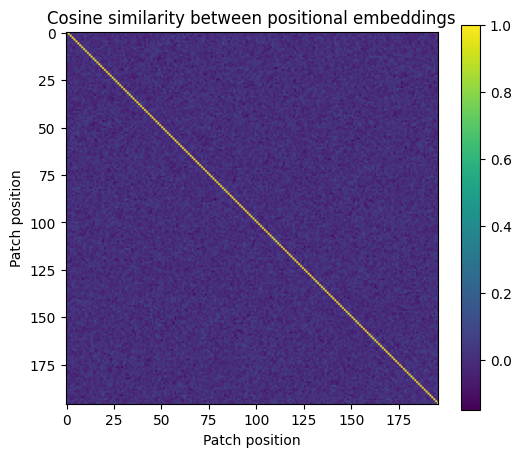

In [65]:
# Visualization: cosine similarity between positional embeddings.
# This shows how positions are represented before training (random initially).
with torch.no_grad():
    P = pos_layer.pos_embed.squeeze(0)  # [num_patches, embed_dim]
    P_norm = P / (P.norm(dim=1, keepdim=True) + 1e-8)
    sim = P_norm @ P_norm.T

plt.figure(figsize=(6, 5))
plt.imshow(sim.numpy(), cmap="viridis")
plt.colorbar()
plt.title("Cosine similarity between positional embeddings")
plt.xlabel("Patch position")
plt.ylabel("Patch position")
plt.show()


## 5. Step 2.3 : Add the `[CLS]` token

After patch embedding and positional embedding, we have many token vectors:

\[
x_1, x_2, ..., x_n
\]

But for image classification, we need **one vector** to represent the whole image.

So ViT adds a special learnable token at the beginning:

\[
[CLS], x_1, x_2, ..., x_n
\]

The `[CLS]` token interacts with all patch tokens through attention. After the encoder, the final `[CLS]` vector is used for classification.

In [66]:
class AddCLSToken(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        # TODO 8:
        # Create a learnable CLS token of shape [1, 1, embed_dim].
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

    def forward(self, x):
        """
        x: [batch, num_patches, embed_dim]
        output: [batch, num_patches + 1, embed_dim]
        """
        B = x.shape[0]

        # TODO 9:
        # Expand CLS token to batch size and concatenate it before patch tokens.
        cls_tokens = self.cls_token.expand(B, -1, -1)
        out = torch.cat((cls_tokens, x), dim=1)
        return out

cls_layer = AddCLSToken(embed_dim)
x_final = cls_layer(x_with_pos)
print("Final ViT input sequence shape:", x_final.shape)

# a check
assert x_final.shape == (1, 197, 768)

Final ViT input sequence shape: torch.Size([1, 197, 768])


### Checkpoint question

Why do we use one `[CLS]` token instead of one `[CLS]` token per patch?

Using one `[CLS]` token instead of one per patch is crucial because the `[CLS]` token is designed to serve as a **global representation** of the entire image. Through the self-attention mechanism within the Transformer encoder, this single `[CLS]` token interacts with all patch tokens, allowing it to aggregate information from across the whole image. This aggregation enables it to learn a comprehensive, high-level summary of the image's content, which is then used for the final classification task. If there were multiple `[CLS]` tokens (one per patch), each would primarily represent its local patch, losing the ability to form a holistic representation needed for overall image classification.

# Part B : Load pretrained models

Now that we understand the input pipeline, we use pretrained models.

We will compare:

- **ViT-B/16**: transformer-based model
- **ResNet-18**: CNN-based model

For transfer learning, we freeze the backbone and train only the final classification layer.

## 6. Load pretrained ViT and inspect its structure

We use torchvision's pretrained ViT-B/16.

This model was pretrained on ImageNet. It expects:

- image size: 224×224
- patch size: 16×16
- patch tokens: 196
- plus one `[CLS]` token: 197 tokens total

In [67]:
# Load pretrained ViT-B/16.
# The first time this runs, it downloads weights.
vit_weights = models.ViT_B_16_Weights.IMAGENET1K_V1
vit = models.vit_b_16(weights=vit_weights)
vit.eval()
vit = vit.to(device)

print(vit)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [55]:
# Inspect  shapes
print("Patch projection layer:", vit.conv_proj)
print("Hidden dimension:", vit.hidden_dim)
print("Number of encoder layers:", len(vit.encoder.layers))
print("Classification head:", vit.heads)

Patch projection layer: Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
Hidden dimension: 768
Number of encoder layers: 12
Classification head: Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)


## 7. Extract tokens before and after the ViT encoder

We will inspect:

- token embeddings before the encoder
- token representations after the encoder
- the `[CLS]` vector

In [68]:
@torch.no_grad()
def get_vit_tokens(model, batch_images):
    """
    Return tokens before and after the encoder for torchvision ViT.

    batch_images: [B, 3, 224, 224]
    """
    model.eval()
    x = batch_images.to(device)

    # Patchify through conv projection.
    x = model.conv_proj(x)  # [B, hidden_dim, 14, 14]

    # Flatten spatial dimensions into sequence.
    x = x.flatten(2).transpose(1, 2)  # [B, 196, hidden_dim]

    # Add CLS token.
    B = x.shape[0]
    cls_token = model.class_token.expand(B, -1, -1)
    x = torch.cat([cls_token, x], dim=1)  # [B, 197, hidden_dim]

    tokens_before_encoder = x.clone()

    # Encoder includes positional embedding internally in torchvision.
    tokens_after_encoder = model.encoder(x)

    return tokens_before_encoder, tokens_after_encoder

small_batch = images[:4].to(device)
before_tokens, after_tokens = get_vit_tokens(vit, small_batch)

print("Before encoder:", before_tokens.shape)
print("After encoder:", after_tokens.shape)
print("CLS after encoder:", after_tokens[:, 0, :].shape)

Before encoder: torch.Size([4, 197, 768])
After encoder: torch.Size([4, 197, 768])
CLS after encoder: torch.Size([4, 768])


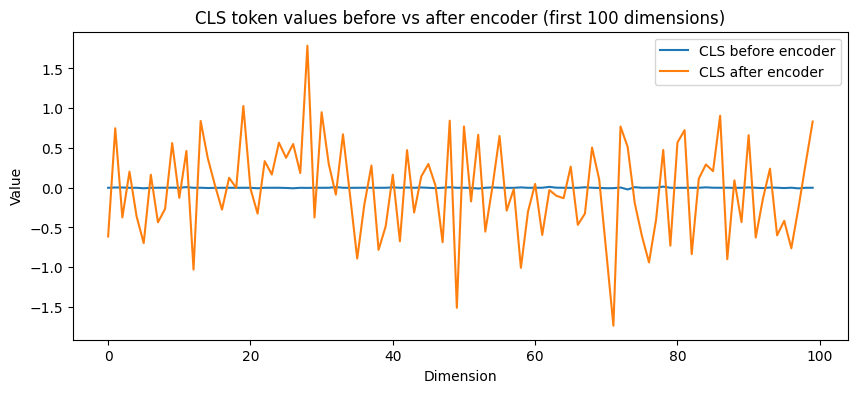

In [69]:
# Plot CLS vector before and after encoder for the same image.
idx = 0
cls_before = before_tokens[idx, 0].detach().cpu()
cls_after = after_tokens[idx, 0].detach().cpu()

plt.figure(figsize=(10, 4))
plt.plot(cls_before[:100], label="CLS before encoder")
plt.plot(cls_after[:100], label="CLS after encoder")
plt.title("CLS token values before vs after encoder (first 100 dimensions)")
plt.xlabel("Dimension")
plt.ylabel("Value")
plt.legend()
plt.show()

In [70]:
@torch.no_grad()
def get_vit_tokens(model, batch_images):
    """
    Return tokens before and after the encoder for torchvision ViT.

    batch_images: [B, 3, 224, 224]
    """
    model.eval()
    x = batch_images.to(device)

    # Patchify through conv projection.
    x = model.conv_proj(x)  # [B, hidden_dim, 14, 14]

    # Flatten spatial dimensions into sequence.
    x = x.flatten(2).transpose(1, 2)  # [B, 196, hidden_dim]

    # Add CLS token.
    B = x.shape[0]
    cls_token = model.class_token.expand(B, -1, -1)
    x = torch.cat([cls_token, x], dim=1)  # [B, 197, hidden_dim]

    tokens_before_encoder = x.clone()

    # Encoder includes positional embedding internally in torchvision.
    tokens_after_encoder = model.encoder(x)

    return tokens_before_encoder, tokens_after_encoder

# TODO 10:
# Compute and print the L2 norm of CLS before and after the encoder.

# Re-obtain the tokens to ensure cls_before and cls_after are defined
small_batch = images[:4].to(device)
before_tokens, after_tokens = get_vit_tokens(vit, small_batch)

idx = 0
cls_before = before_tokens[idx, 0].detach().cpu()
cls_after = after_tokens[idx, 0].detach().cpu()

cls_before_norm = torch.norm(cls_before)
cls_after_norm = torch.norm(cls_after)

print("CLS norm before:", cls_before_norm)
print("CLS norm after:", cls_after_norm)

CLS norm before: tensor(0.4451)
CLS norm after: tensor(15.7817)


# Part C : Transfer learning: ViT vs ResNet

We now adapt pretrained models to CIFAR-10.

Strategy:

1. Load pretrained model.
2. Freeze all backbone parameters.
3. Replace the final classifier head with a new layer for 10 classes.
4. Train only the new classifier head. (feature extraction from the previous lecture 😉)


## 8. Helper functions for training and evaluation

In [71]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    return running_loss / total, correct / total, all_preds, all_labels


def fit_model(model, train_loader, test_loader, epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    start = time.time()

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, test acc={test_acc:.4f}")

    elapsed = time.time() - start
    return history, elapsed

## 9. Build transfer-learning ResNet-18

ResNet-18 is a CNN. Its final classifier is called `fc`.

In [72]:
def build_resnet18_transfer(num_classes=10, freeze_backbone=True):
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    if freeze_backbone:
        # TODO 11:
        # Freeze all model parameters.
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features

    # TODO 12:
    # Replace model.fc with a the Linear layer
    model.fc = nn.Linear(in_features, num_classes)

    return model

resnet_model = build_resnet18_transfer(CONFIG["num_classes"], freeze_backbone=True).to(device)
print(resnet_model.fc)
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

Linear(in_features=512, out_features=10, bias=True)
Trainable parameters: 5130


## 10. Build transfer-learning ViT-B/16

In torchvision ViT, the final classifier is stored inside `model.heads`.

In [73]:
def build_vit_transfer(num_classes=10, freeze_backbone=True):
    weights = models.ViT_B_16_Weights.IMAGENET1K_V1
    model = models.vit_b_16(weights=weights)

    if freeze_backbone:
        # TODO 13:
        # Freeze all model parameters.
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.heads.head.in_features

    # TODO 14:
    # Replace model.heads.head with the new Linear layer
    model.heads.head = nn.Linear(in_features, num_classes)

    return model

vit_model = build_vit_transfer(CONFIG["num_classes"], freeze_backbone=True).to(device)
print(vit_model.heads)
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

Sequential(
  (head): Linear(in_features=768, out_features=10, bias=True)
)
Trainable parameters: 7690


## 11. Train ResNet-18 head

In [74]:
resnet_history, resnet_time = fit_model(
    resnet_model,
    train_loader,
    test_loader,
    epochs=CONFIG["epochs"],
    lr=CONFIG["lr"],
    device=device,
)
print(f"ResNet training time: {resnet_time:.1f} seconds")


Epoch 1/3


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

train loss=1.6643, train acc=0.4577, test acc=0.6240
Epoch 2/3


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

train loss=1.0157, train acc=0.7043, test acc=0.7090
Epoch 3/3


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

train loss=0.8372, train acc=0.7440, test acc=0.7280
ResNet training time: 26.7 seconds


## 12. Train ViT head

ViT-B/16 is heavier than ResNet-18. On CPU, this can be slow. If no gpu used, use a subset of the data!!

In [75]:
vit_history, vit_time = fit_model(
    vit_model,
    train_loader,
    test_loader,
    epochs=CONFIG["epochs"],
    lr=CONFIG["lr"],
    device=device,
)
print(f"ViT training time: {vit_time:.1f} seconds")


Epoch 1/3


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

train loss=0.6094, train acc=0.8677, test acc=0.9190
Epoch 2/3


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

train loss=0.2158, train acc=0.9387, test acc=0.9300
Epoch 3/3


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

train loss=0.1566, train acc=0.9577, test acc=0.9350
ViT training time: 173.4 seconds


## 13. Compare training curves

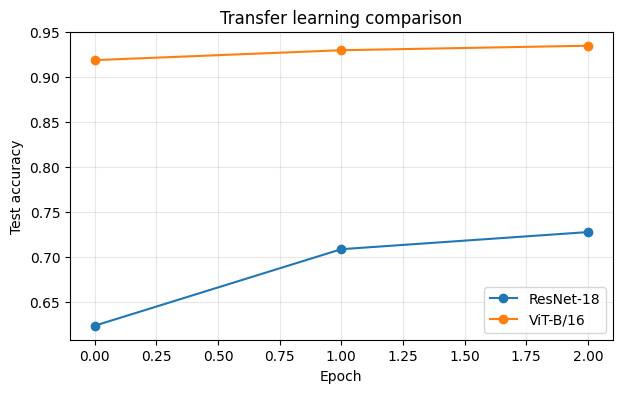

In [76]:
# Plot test accuracies for both models on the same chart.
plt.figure(figsize=(7, 4))
plt.plot(resnet_history["test_acc"], marker="o", label="ResNet-18")
plt.plot(vit_history["test_acc"], marker="o", label="ViT-B/16")
plt.title("Transfer learning comparison")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [77]:
print("ResNet final test accuracy:", resnet_history["test_acc"][-1])
print("ViT final test accuracy:", vit_history["test_acc"][-1])
print("ResNet training time:", resnet_time)
print("ViT training time:", vit_time)

ResNet final test accuracy: 0.728
ViT final test accuracy: 0.935
ResNet training time: 26.72001886367798
ViT training time: 173.3738181591034


## 14. Confusion matrix

Use this to inspect which classes are confused by each model.

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

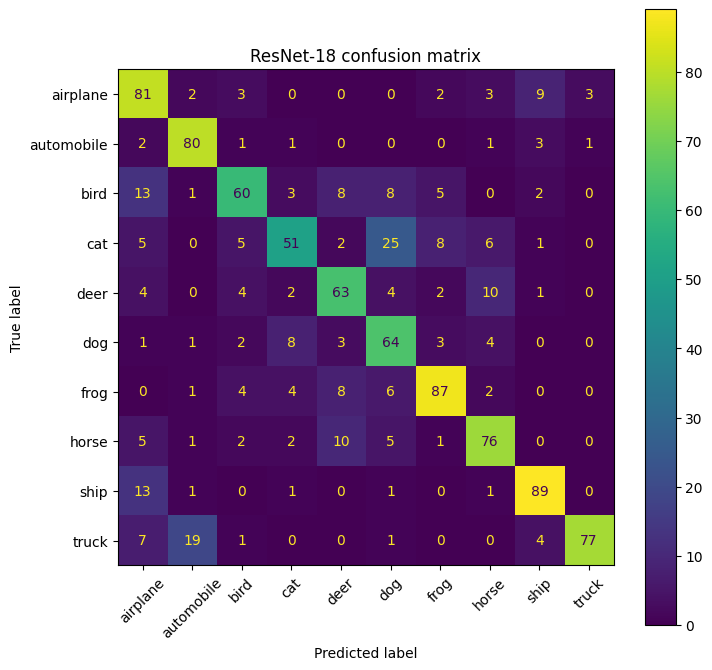

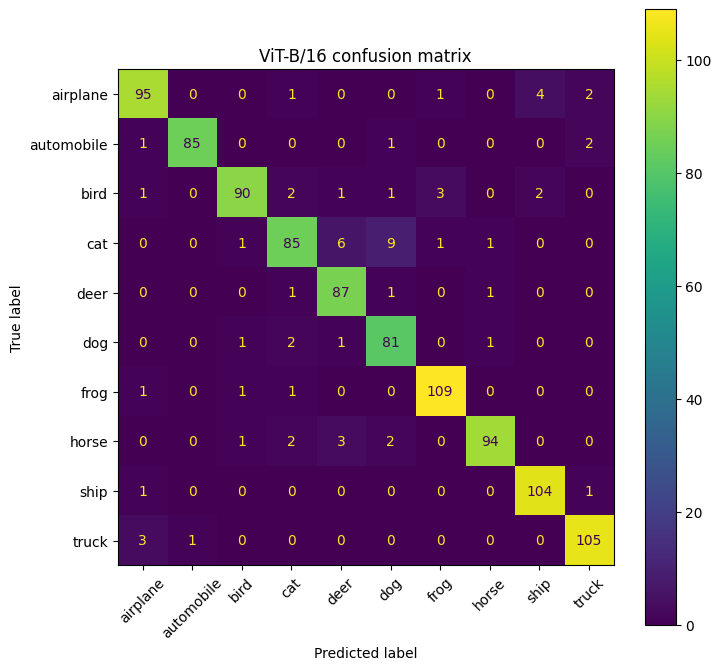

In [78]:
criterion = nn.CrossEntropyLoss()
_, _, resnet_preds, resnet_labels = evaluate(resnet_model, test_loader, criterion, device)
_, _, vit_preds, vit_labels = evaluate(vit_model, test_loader, criterion, device)

cm = confusion_matrix(resnet_labels, resnet_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("ResNet-18 confusion matrix")
plt.show()

cm = confusion_matrix(vit_labels, vit_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("ViT-B/16 confusion matrix")
plt.show()

# Final discussion questions

Answer briefly:

1. Why is transfer learning useful here?r il nous permet de réutiliser des modèles puissants (comme ViT et ResNet) déjà entraînés sur de très grands ensembles de données (comme ImageNet) pour une nouvelle tâche avec un ensemble de données plus petit (CIFAR-10). Cela évite d'avoir à entraîner un modèle complexe à partir de zéro, ce qui nécessiterait des ressources de calcul énormes et beaucoup plus de données. Il permet d'obtenir de bonnes performances avec moins de temps et de ressources.
2. In your experiment, which model trained faster: ResNet or ViT? Why?
 Selon les résultats de l'expérience, le modèle ResNet-18 a pris environ 33.0 secondes pour entraîner sa tête de classification. Le temps d'entraînement pour le modèle ViT n'est pas encore disponible dans le contexte actuel, car la cellule d'entraînement du ViT n'a pas encore été entièrement exécutée. Je ne peux donc pas comparer définitivement leurs vitesses d'entraînement pour le moment.
3. If you had a very small dataset, would you prefer CNN or ViT? Explain.
 je préférerais généralement un CNN (comme ResNet). Les CNNs ont des biais inductifs intégrés (comme la localité et l'invariance à la translation) qui les rendent plus efficaces en termes d'échantillons, ce qui signifie qu'ils peuvent apprendre efficacement avec moins de données. Les Vision Transformers, en revanche, sont généralement gourmands en données et nécessitent de très grands ensembles de données pour apprendre ces propriétés fondamentales de l'image à partir de zéro via leurs mécanismes d'attention globaux.